# tableros bien horizontales

In [1]:
import cv2
import matplotlib.pyplot as plt

¡Éxito! Se detectó el recuadro exterior del tablero.


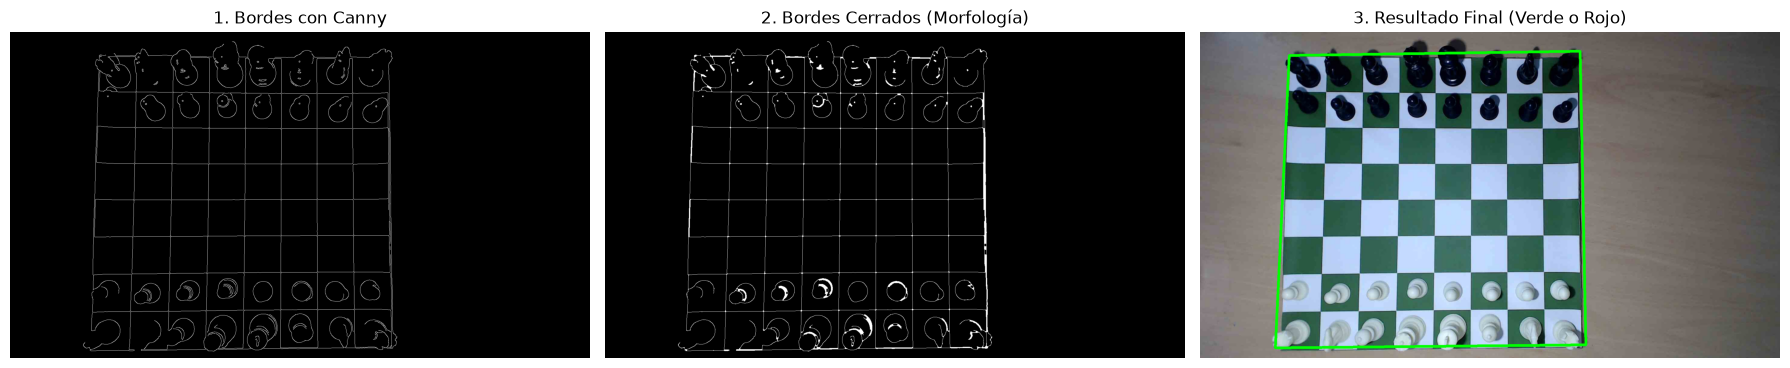

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar la imagen
ruta = "../../data/raw/tablero_vertical.jpg"
imagen_gris = cv2.imread(ruta, 0)
imagen_color = cv2.imread(ruta)
imagen_color = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB)

if imagen_gris is None:
    print("No se pudo cargar la imagen. Revisa la ruta.")
else:
    # 2. SUAVIZADO: Eliminamos imperfecciones o texturas sutiles
    desenfocado = cv2.GaussianBlur(imagen_gris, (5, 5), 0)
    
    # 3. CANNY (REALCE DE BORDES): Busca cambios bruscos de intensidad.
    # Los valores 50 y 150 son los umbrales de sensibilidad.
    bordes_canny = cv2.Canny(desenfocado, 50, 150)
    
    # 4. OPERACIÓN MORFOLÓGICA (CIERRE): Creamos un "bloque" de 5x5 píxeles
    # para conectar líneas del borde exterior que hayan quedado separadas o rotas.
    kernel = np.ones((5, 5), np.uint8)
    bordes_cerrados = cv2.morphologyEx(bordes_canny, cv2.MORPH_CLOSE, kernel)
    
    # 5. ENCONTRAR CONTORNOS: Buscamos solo el contorno más externo
    contornos, _ = cv2.findContours(bordes_cerrados, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Ordenamos por tamaño (área) de mayor a menor
    contornos = sorted(contornos, key=cv2.contourArea, reverse=True)
    
    tablero_esquinas = None
    
    # 6. FILTRAR POR RECTÁNGULO: Buscamos cuál de los contornos grandes tiene 4 esquinas
    for c in contornos:
        perimetro = cv2.arcLength(c, True)
        aproximacion = cv2.approxPolyDP(c, 0.02 * perimetro, True)
        
        if len(aproximacion) == 4:
            tablero_esquinas = aproximacion
            break
            
    # 7. DIBUJAR Y MOSTRAR TODO EL PROCESO
    if tablero_esquinas is not None:
        print("¡Éxito! Se detectó el recuadro exterior del tablero.")
        cv2.drawContours(imagen_color, [tablero_esquinas], -1, (0, 255, 0), 7)
    else:
        print("No se encontró un contorno exterior de 4 esquinas perfecto.")
        print("Intentaremos dibujar el contorno más grande que encontró (tenga o no 4 esquinas) para ver qué pasó:")
        if len(contornos) > 0:
            cv2.drawContours(imagen_color, [contornos[0]], -1, (255, 0, 0), 5)

    # Bloque de visualización en Jupyter para diagnóstico
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    axs[0].imshow(bordes_canny, cmap='gray')
    axs[0].set_title("1. Bordes con Canny")
    axs[0].axis('off')
    
    axs[1].imshow(bordes_cerrados, cmap='gray')
    axs[1].set_title("2. Bordes Cerrados (Morfología)")
    axs[1].axis('off')
    
    axs[2].imshow(imagen_color)
    axs[2].set_title("3. Resultado Final (Verde o Rojo)")
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()

entonces anda bien